### Імпорт бібліотек, встановлення налаштувань відображення, завантаження файлу

In [304]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [305]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

In [306]:
df = pd.read_csv("D:\\my_projects\\kursah\\data\\raw\\result_test_5000.csv")

In [307]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   price_UAH           5000 non-null   str  
 1   price_USD           5000 non-null   str  
 2   title               5000 non-null   str  
 3   location_list       5000 non-null   str  
 4   details_list        5000 non-null   str  
 5   advantages_list     5000 non-null   str  
 6   description         5000 non-null   str  
 7   created_at          5000 non-null   str  
 8   facilities_list     5000 non-null   str  
 9   technically_tested  5000 non-null   str  
 10  seller_name         5000 non-null   str  
 11  seller_trust        5000 non-null   str  
 12  city                5000 non-null   str  
 13  plus_text           5000 non-null   str  
 14  url                 5000 non-null   str  
 15  page                5000 non-null   int64
dtypes: int64(1), str(15)
memory usage: 625.1 KB


## 1. Очистка і формування стовпчиків для аналізу

### Загальні стовпці з ціною, id, кількістю кімнат

In [308]:
df['id'] = df['title'].str.extract(r'ID (\d+)').astype(int)
df['rooms'] = df['title'].str.extract(r'(\d+)к квартири').astype(int)
df['price_UAH'] = df['price_UAH'].str.replace(' ', '').str.extract(r'(\d+)').astype(int)
df['price_USD'] = df['price_USD'].str.replace(' ', '').str.extract(r'(\d+)').astype(int)

### Стовпець дати

In [309]:
months = {
    'січ': '01', 'лют': '02', 'бер': '03', 'кві': '04',
    'тра': '05', 'чер': '06', 'лип': '07', 'сер': '08',
    'вер': '09', 'жов': '10', 'лис': '11', 'гру': '12'
}
extracted = df['created_at'].str.extract(r'(\d+)\s+([а-яіїєґ]+)\.*\s*(\d{4})?')
extracted.columns = ['day', 'month_abbr', 'year']
current_year = str(pd.Timestamp.now().year)
extracted['year'] = extracted['year'].fillna(current_year)
extracted['month'] = extracted['month_abbr'].map(months)

df['date'] = pd.to_datetime(
    extracted['day'] + '.' + extracted['month'] + '.' + extracted['year'],
    format='%d.%m.%Y'
)

### Створення стовпців з локацією

In [310]:
df['city_name'] = df['city'].str.split(',').str[2].str.strip().astype(str)
df['district'] = df['location_list'].str.extract(r'район\s+([^|]+)')[0].str.strip()
df['metro'] = df['location_list'].str.extract(r'метро\s+([^|]+)')[0].str.strip()
df['address'] = df['title'].str.extract(r'на\s+((?:вул|просп|бул|пров|пл|шосе|наб)\.?\s+.+?)(?=\s*•)')[0].str.strip()

### Створення стовпців з інформацією про продавця

In [311]:
df['seller'] = df['seller_name'].str.extract(r'\n([А-ЯІЇЄҐа-яA-Za-z][^\n\d]+?)(?:\n|$)')[0].str.strip()

def experience_to_months(text):
    if pd.isna(text):
        return 0
    
    years  = re.search(r'(\d+)\+?\s*рок|(\d+)\+?\s*рік', text)
    months = re.search(r'(\d+)\s*місяц', text)
    days   = re.search(r'(\d+)\s*дн', text)
    
    total = 0
    if years:
        total += int(years.group(1) or years.group(2)) * 12
    if months:
        total += int(months.group(1))
    if days:
        total += int(days.group(1)) / 30
    
    return total

def categorize(months):
    if months < 12:
        return 'Новачок'        # < 1 року
    elif months < 36:
        return 'Досвідчений'     # 1–3 роки
    elif months < 60:
        return 'Професіонал'  # 3–5 років
    else:
        return 'Експерт'      # 5+ років
    
df['experience_months'] = df['seller_trust'].apply(experience_to_months).round().astype(int)
df['seller_level'] = df['experience_months'].apply(categorize)

print(df[['experience_months', 'seller_level']].head(10))

   experience_months seller_level
0                 60      Експерт
1                 60      Експерт
2                 60      Експерт
3                 60      Експерт
4                 60      Експерт
5                 60      Експерт
6                 60      Експерт
7                 60      Експерт
8                 60      Експерт
9                  5      Новачок


### Створення стовпців по площі 

In [312]:
df['area_total']   = df['details_list'].str.extract(r'[Зз]агальна площа\s+([\d.]+)')[0]
df['area_living']  = df['details_list'].str.extract(r'житлова\s+([\d.]+)')[0]
df['area_kitchen'] = df['details_list'].str.extract(r'кухня\s+([\d.]+)')[0]

for col in ['area_total', 'area_living', 'area_kitchen']:
    df[col] = df[col].astype(float)

print(df[['area_total', 'area_living', 'area_kitchen']].head(10))

   area_total  area_living  area_kitchen
0        27.0         16.0           6.0
1        87.0         60.0          20.0
2       140.0         55.4          34.2
3        40.0          NaN          18.8
4        51.2         14.7          23.6
5        44.1          NaN           NaN
6        21.0         14.0           4.0
7        26.0         14.0           4.0
8        46.0          NaN           NaN
9        30.0         16.0           6.0


### Створення стовпців поверху квартири та поверховості будинку

In [313]:
df['floor_current'] = df['technically_tested'].str.extract(r'(\d+)\s+поверх з')[0].astype('Int64')
df['floor_total']   = df['technically_tested'].str.extract(r'поверх з\s+(\d+)')[0].astype('Int64')

print(df[['floor_current', 'floor_total']].head(10))

   floor_current  floor_total
0              3            4
1              5           16
2              7            8
3              4            9
4             23           26
5             10           16
6              2            3
7              1            2
8              4           15
9              2            2


### Створення бінарних стовпців по особливостям планування

In [314]:
df['kitchen_studio'] = df['plus_text'].str.extract(r'(Кухня-студія)', flags=re.IGNORECASE)
df['penthouse']      = df['plus_text'].str.extract(r'(Пентхаус)', flags=re.IGNORECASE)
df['multilevel']     = df['plus_text'].str.extract(r'(Багаторівнева)', flags=re.IGNORECASE)

for col in ['kitchen_studio', 'penthouse', 'multilevel']:
    df[col] = df[col].notna().astype(int)

print(df[['kitchen_studio', 'penthouse', 'multilevel']].head(20))

    kitchen_studio  penthouse  multilevel
0                1          0           0
1                1          0           0
2                1          1           1
3                1          0           0
4                1          0           0
5                1          0           0
6                0          0           0
7                1          0           0
8                0          0           0
9                0          0           0
10               0          0           0
11               0          0           0
12               0          0           0
13               0          0           0
14               1          1           1
15               1          0           0
16               1          0           0
17               0          0           0
18               1          0           0
19               0          0           0


### Створення стовпця про наявність укриття 

In [315]:
df['shelter'] = df['advantages_list'].str.extract(r'((?:У|у)криття[^|]+)')[0].str.strip()

def extract_shelter_context(text):
    if pd.isna(text):
        return None
    match = re.search(r'(\S+\s+){0,2}\S*[Уу]крит\S*(\s+\S+){0,2}', text)
    return match.group().strip() if match else None

df['shelter_context'] = df['description'].apply(extract_shelter_context)
df['shelter_plus'] = df['plus_text'].apply(extract_shelter_context)

print(df['shelter'].head(10))

0    Укриття в будинку
1                  NaN
2                  NaN
3                  NaN
4                  NaN
5                  NaN
6                  NaN
7                  NaN
8                  NaN
9                  NaN
Name: shelter, dtype: str


Зведення до єдиної бінарної колонки по наявності укриття:

In [316]:
df['shelter_plus'] = df['shelter_plus'].str.contains('укриття', case=False, na=False).astype(int)
df['shelter_context'] = df['shelter_context'].str.contains('укриття', case=False, na=False).astype(int)
df['shelter'] = df['shelter'].str.contains('укриття', case=False, na=False).astype(int)

shelter_columns = ['shelter_plus', 'shelter_context', 'shelter']
df['has_shelter'] = df[shelter_columns].any(axis=1).astype(int)


# print(df[['shelter_plus', 'shelter_context', 'shelter']])
print(df['has_shelter'].value_counts())

has_shelter
0    3773
1    1227
Name: count, dtype: int64


### Створення стовпця дозволу проживання з тваринами

In [317]:
df['pets'] = df['facilities_list'].str.extract(r'((?:[Мм]ожна|[Нн]е можна|[Бб]ез)\s+з?\s*тварин[^|]*)')[0].str.strip()

def extract_bober_context(text):
    if pd.isna(text):
        return None
    match = re.search(r'(\S+\s+){0,2}\S*[Тт]варин\S*(\s+\S+){0,2}', text)
    return match.group().strip() if match else None

df['pets_desc'] = df['description'].apply(extract_bober_context)

Зведення до єдиної бінарної колонки по дозволу проживання з тваринами:

In [318]:
df['pets'] = df['pets'].fillna('Не вказано')

def classify_pets_desc(text):
    if pd.isna(text):
        return None
    text_lower = text.lower()
    
    if re.search(r'без тварин|не можна|заборон|неможлив|не приймаємо тварин|не розглядаєть|не розглядаємо', text_lower):
        return 'не можна'
    
    if re.search(r'тварин|тваринк', text_lower):
        return 'можна'
    
    return None

df['pets_classified'] = df['pets_desc'].apply(classify_pets_desc)

df['pets'] = df['pets'].fillna(df['pets_classified']).fillna('не вказано')


print(df['pets'].value_counts())

pets
Не вказано           2573
Без тварин           1519
Можна з тваринами     908
Name: count, dtype: int64


### Створення стовпців забезпеченості при відсутності електроенергії.   

In [319]:
features = {
    'no_light_internet':    'є інтернет',
    'no_light_mobile_connection':      'є мобільний зв\'язок',
    'no_light_water':       'є водопостачання',
    'no_light_heating':     'працює опалення',
    'no_light_gas':         'є газ',
    'no_light_elevator':    'працює ліфт'
}

for col, keyword in features.items():
    df[col] = df['plus_text'].str.contains(keyword, case=False, na=False).astype(int)

df[['no_light_internet', 'no_light_mobile_connection', 'no_light_water', 'no_light_heating', 'no_light_gas',
           'no_light_elevator']].head(10)

,no_light_internet,no_light_mobile_connection,no_light_water,no_light_heating,no_light_gas,no_light_elevator
0,1,0,0,0,0,0
1,1,0,1,1,0,1
2,1,0,1,1,1,0
3,0,0,0,0,0,0
4,1,1,1,1,0,1
5,0,1,1,0,0,0
6,1,1,1,0,0,0
7,1,1,1,0,0,0
8,0,0,0,0,0,0
9,1,0,0,1,1,0


### **Створення кінцевого датасету**

In [320]:
cl_df = df[['id', 'rooms', 'price_UAH', 'price_USD', 'date', 'city_name', 'district', 'metro', 'address', 'seller',
            'experience_months', 'seller_level', 'area_total', 'area_living', 'area_kitchen', 'floor_current', 
            'floor_total', 'kitchen_studio', 'penthouse', 'multilevel', 'has_shelter', 'pets', 'no_light_internet',
            'no_light_mobile_connection', 'no_light_water', 'no_light_heating', 'no_light_gas', 'no_light_elevator',
            'url']].copy()

print(cl_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id                          5000 non-null   int64         
 1   rooms                       5000 non-null   int64         
 2   price_UAH                   5000 non-null   int64         
 3   price_USD                   5000 non-null   int64         
 4   date                        5000 non-null   datetime64[us]
 5   city_name                   4963 non-null   str           
 6   district                    4383 non-null   str           
 7   metro                       1310 non-null   str           
 8   address                     4897 non-null   str           
 9   seller                      5000 non-null   str           
 10  experience_months           5000 non-null   int64         
 11  seller_level                5000 non-null   str           
 12  are

## 2. EDA (Exploratory Data Analysis)

### 1. Обробка пропущених значень

In [321]:
cl_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id                          5000 non-null   int64         
 1   rooms                       5000 non-null   int64         
 2   price_UAH                   5000 non-null   int64         
 3   price_USD                   5000 non-null   int64         
 4   date                        5000 non-null   datetime64[us]
 5   city_name                   4963 non-null   str           
 6   district                    4383 non-null   str           
 7   metro                       1310 non-null   str           
 8   address                     4897 non-null   str           
 9   seller                      5000 non-null   str           
 10  experience_months           5000 non-null   int64         
 11  seller_level                5000 non-null   str           
 12  are

#### Перевірка і видалення дублікатів

Спочатку перевіряємо повністю дублюючі рядки і видаляємо дублікати. 

In [322]:
n_duplicates = cl_df.duplicated().sum()
print(f"Кількість повних дублікатів: {n_duplicates}")
print(f"Це {n_duplicates / len(cl_df) * 100:.2f}% від усіх рядків ({len(cl_df)} загалом)")

cl_df = cl_df.drop_duplicates()
print(f"\nПісля видалення: {len(cl_df)} рядків залишилось")

Кількість повних дублікатів: 68
Це 1.36% від усіх рядків (5000 загалом)

Після видалення: 4932 рядків залишилось


Далі перевіряємо і видаляємо дублікати по колонці `id`

In [323]:
n_duplicates_id = cl_df.duplicated(subset=['id']).sum()
print(f"Кількість дублікатів по колонці id: {n_duplicates_id}")
print(f"Це {n_duplicates_id / len(cl_df) * 100:.2f}% від усіх рядків ({len(cl_df)} загалом)")

cl_df = cl_df.drop_duplicates(subset=['id'])
print(f"\nПісля видалення: {len(cl_df)} рядків залишилось")

Кількість дублікатів по колонці id: 4
Це 0.08% від усіх рядків (4932 загалом)

Після видалення: 4928 рядків залишилось


Додатково перевіряємо і видаляємо дублікати за ціною, площею та адресою. Скоріш за все це спам рієлторів для підняття оголошень в топ при повторному опублікуванні.

In [324]:
# 1. Рахуємо загальну кількість "схованих" дублікатів
columns_to_check = ['price_UAH', 'rooms', 'area_total', 'floor_current', 'address']
dup_count = cl_df.duplicated(subset=columns_to_check).sum()

print(f"Знайдено прихованих дублікатів (рієлторського спаму): {dup_count}")

# 2. Дістаємо всі ці рядки (і оригінали, і їхні копії)
semantic_duplicates = cl_df[cl_df.duplicated(subset=columns_to_check, keep=False)]

# 3. Виводимо їх на екран, відсортувавши за ціною та площею
if not semantic_duplicates.empty:
    print("\nОсь як вони виглядають:")
    print(semantic_duplicates.sort_values(by=['price_UAH', 'area_total'])[
        ['id', 'price_UAH', 'rooms', 'area_total', 'floor_current', 'address']
    ].head(20))

Знайдено прихованих дублікатів (рієлторського спаму): 51

Ось як вони виглядають:
            id  price_UAH  rooms  area_total  floor_current  \
1863  34036223       6000      1        22.0              6   
3254  33989698       6000      1        22.0              6   
818   34002589       7000      1        34.0              5   
829   34005038       7000      1        34.0              5   
2460  34006544       7000      1        35.0              1   
2703  33301803       7000      1        35.0              1   
636   34062990       7000      2        42.0              3   
872   34064907       7000      2        42.0              3   
1781  34040910       7500      1        25.0              1   
1818  34040825       7500      1        25.0              1   
141   34074162       8000      1        33.0              4   
575   34061867       8000      1        33.0              4   
2643  24728984      10000      1        38.0             14   
2645  24705942      10000      1    

In [325]:
print(f"Довжина датасету до видалення дублікатів: {len(cl_df)}")
cl_df = cl_df.drop_duplicates(subset=['price_UAH', 'rooms', 'area_total', 'floor_current', 'address'], keep='first')
print(f"Довжина датасету після видалення дублікатів: {len(cl_df)}")

Довжина датасету до видалення дублікатів: 4928
Довжина датасету після видалення дублікатів: 4877


Також видаляємо схожі оголошення від одного автора за основною колонкою `seller`

In [326]:
# 1. Рахуємо загальну кількість "схованих" дублікатів
columns_to_check = ['price_UAH', 'rooms', 'area_total', 'floor_current', 'seller']
dup_count = cl_df.duplicated(subset=columns_to_check).sum()

print(f"Знайдено прихованих дублікатів (рієлторського спаму): {dup_count}")

# 2. Дістаємо всі ці рядки (і оригінали, і їхні копії)
semantic_duplicates = cl_df[cl_df.duplicated(subset=columns_to_check, keep=False)]

# 3. Виводимо їх на екран, відсортувавши за ціною та площею
if not semantic_duplicates.empty:
    print("\nОсь як вони виглядають:")
    print(semantic_duplicates.sort_values(by=['price_UAH', 'area_total'])[
        ['id', 'price_UAH', 'rooms', 'area_total', 'floor_current', 'seller']
    ].head(20)) # Виводимо перші 20 рядків для оцінки

Знайдено прихованих дублікатів (рієлторського спаму): 3

Ось як вони виглядають:
            id  price_UAH  rooms  area_total  floor_current  \
2720  34012904       4405      1        34.0              3   
4201  33930357       4405      1        34.0              3   
2463  34021293      10000      1        30.0              2   
2698  34013205      10000      1        30.0              2   
661   34067991      70480      1        51.5             12   
4976  33867414      70480      1        51.5             12   

                        seller  
2720             Анна Тодорова  
4201             Анна Тодорова  
2463                     Илона  
2698                     Илона  
661   Яна Юріївна Мірошніченко  
4976  Яна Юріївна Мірошніченко  


In [327]:
print(f"Довжина датасету до видалення дублікатів: {len(cl_df)}")
cl_df = cl_df.drop_duplicates(subset=['price_UAH', 'rooms', 'area_total', 'floor_current', 'seller'], keep='first')
print(f"Довжина датасету після видалення дублікатів: {len(cl_df)}")

Довжина датасету до видалення дублікатів: 4877
Довжина датасету після видалення дублікатів: 4874


Також виконаємо пошук незважаючи на ціну і площу (їх можуть спеціально змінювати агенства) за кількістю кімнат, поверхом і адресою. Таким чином ми знайшли великий шматок дублікатів від різних рієлторів одних і тих самих квартир - їх ми видаляємо.

In [328]:
sneaky_duplicates = cl_df[cl_df.duplicated(subset=['rooms', 'floor_current', 'address'], keep=False)]

if not sneaky_duplicates.empty:
    print("Знайдено квартири за однаковою адресою, але з різною ціною/площею:")
    print(f"Знайдено рієлторських дублікатів: {len(sneaky_duplicates)}")
    print(sneaky_duplicates.sort_values(by=['address', 'floor_current'])[
        ['address', 'floor_current', 'price_UAH', 'area_total', 'seller', 'url']
    ].head(20))
else:
    print("Все ідеально чисто, хитрих дублікатів немає!")

Знайдено квартири за однаковою адресою, але з різною ціною/площею:
Знайдено рієлторських дублікатів: 417
                         address  floor_current  price_UAH  area_total  \
130           вул. 600-річчя 66В              9      17000        50.0   
3375          вул. 600-річчя 66В              9      18000        50.0   
2606          вул. 600-річчя 66В             10      17000        52.0   
3829          вул. 600-річчя 66В             10      17000        49.0   
246           вул. Європейська 3              5       7000        34.0   
3595          вул. Європейська 3              5      13500        40.0   
3714      вул. А. Манастирського              1      11894        70.0   
4655      вул. А. Манастирського              1      12000        70.0   
2851  вул. Академіка Заболотного              1      16300        55.0   
2904  вул. Академіка Заболотного              1       6000        48.0   
2356       вул. Академіка Янгеля              2      11500        36.0   
4006   

In [329]:
print(f"Довжина датасету до видалення дублікатів: {len(cl_df)}")

cl_df = cl_df.drop_duplicates(subset=['rooms', 'floor_current', 'address'], keep='first')

print(f"Готово! Залишилося унікальних реальних квартир: {len(cl_df)}")

Довжина датасету до видалення дублікатів: 4874
Готово! Залишилося унікальних реальних квартир: 4634


#### Видалення пустих рядків і заповнення

Просто видаляємо колонки з відсутнім поверхом, їх небагато. Це може бути через неперевірену квартиру або збій - обидва варіанти нам не підходять.

In [330]:
print(f"До: {len(cl_df)}")
cl_df = cl_df.dropna(subset=['floor_current'])
print(f"Після: {len(cl_df)}")

До: 4634
Після: 4624


В наступних комірках заповнюємо пропущені значення медіаною групи і загальною. Це так звана Імпутація. Оскільки це площа кухні і житлова за орієнтир беремо кількість кімнат. Також порівнюємо медіану і середнє до та після заповнення.

In [331]:
print(cl_df['area_kitchen'].median())
print(cl_df['area_kitchen'].mean())
print(cl_df['area_living'].median())
print(cl_df['area_living'].mean())

11.8
12.714884505580066
28.0
32.45230679498396


In [332]:
# Заповнюємо площу медіаною на основі кількості кімнат
cl_df['area_living'] = cl_df['area_living'].fillna(
    cl_df.groupby('rooms')['area_living'].transform('median')
)


cl_df['area_kitchen'] = cl_df['area_kitchen'].fillna(
    cl_df.groupby('rooms')['area_kitchen'].transform('median')
)

# Залишок заповнюємо просто загальною медіаною
cl_df['area_kitchen'] = cl_df['area_kitchen'].fillna(cl_df['area_kitchen'].median())
cl_df['area_living'] = cl_df['area_living'].fillna(cl_df['area_living'].median())

In [333]:
print(cl_df['area_kitchen'].median())
print(cl_df['area_kitchen'].mean())
print(cl_df['area_living'].median())
print(cl_df['area_living'].mean())

11.3
12.463256920415224
28.0
31.349093858131493


Після заповнення пропусків спостерігаються незначні зміни у середньому значення та медіані, проте вони не спотворюють загальні дані і знаходяться в межах дозволеного. 

Також далі видаляємо рядки без адреси і без міста, їх теж небагато.

In [334]:
cl_df = cl_df.dropna(subset=['address'])
cl_df = cl_df.dropna(subset=['city_name'])

Ще заповнюємо відсутні значення у стовпці метро 'Немає метро' і створюємо для майбутніх дій бінарний стовпець 'has_metro'.
Відсутні значення у стовпці район також заповнюємо 'Невідомий район'.

In [335]:
cl_df['metro'] = cl_df['metro'].fillna('Немає метро')
cl_df['has_metro'] = (cl_df['metro'] != 'Немає метро').astype(int)


cl_df['district'] = cl_df['district'].fillna('Невідомий район')

Дивимося на результат заповнення порожніх комірок: маємо 4550 з 5000, тобто це 91% - можна сказати чудовий результат після парсера сайта і очищення даних за допомогою регулярних виразів.

In [336]:
cl_df.info()

<class 'pandas.DataFrame'>
Index: 4555 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id                          4555 non-null   int64         
 1   rooms                       4555 non-null   int64         
 2   price_UAH                   4555 non-null   int64         
 3   price_USD                   4555 non-null   int64         
 4   date                        4555 non-null   datetime64[us]
 5   city_name                   4555 non-null   str           
 6   district                    4555 non-null   str           
 7   metro                       4555 non-null   str           
 8   address                     4555 non-null   str           
 9   seller                      4555 non-null   str           
 10  experience_months           4555 non-null   int64         
 11  seller_level                4555 non-null   str           
 12  area_tot

### 2. Перевірка викидів

Спочатку розподілимо колонки по групам для зручності аналізу.

In [337]:
numeric_cols = [
    'price_UAH', 'price_USD',
    'area_total', 'area_living', 'area_kitchen',
    'floor_current', 'floor_total',
    'experience_months', 'rooms'
]

binary_cols = [
    'kitchen_studio', 'penthouse', 'multilevel', 'has_shelter',
    'no_light_internet', 'no_light_mobile_connection',
    'no_light_water', 'no_light_heating', 'no_light_gas',
    'no_light_elevator', 'has_metro'
]

categorical_cols = ['seller_level', 'pets', 'city_name', 'district']

#### 1. Візуалізація (боксплоти)

Використаємо `Boxplots` для наочного виявлення аномалій.

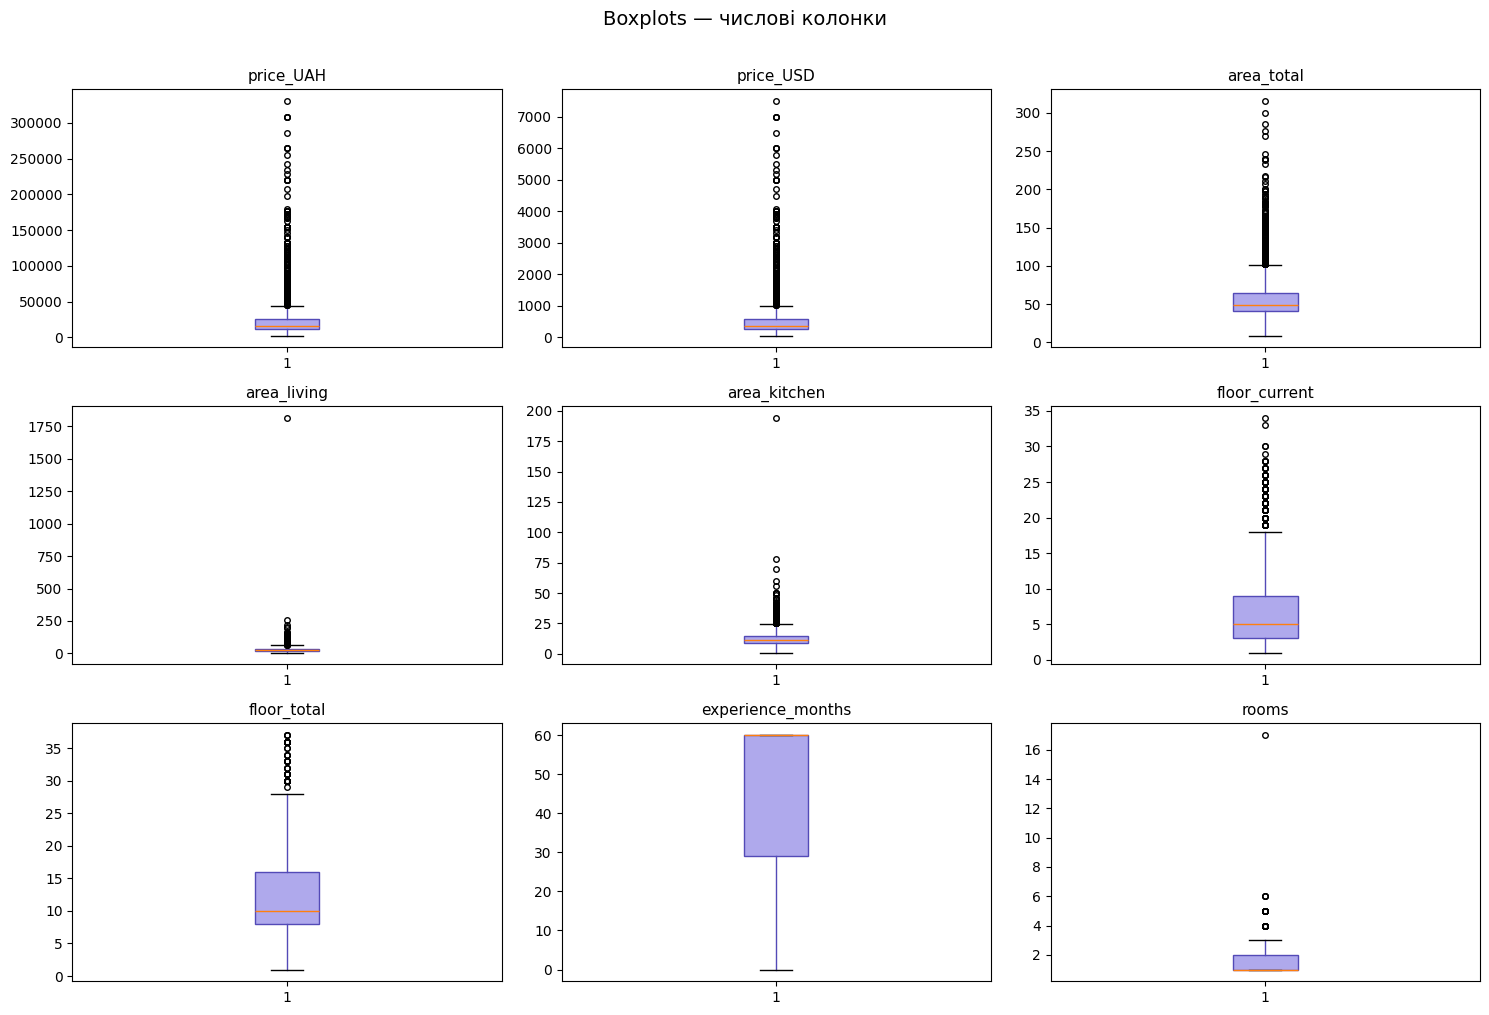

In [338]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(cl_df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#AFA9EC', color='#534AB7'),
                    whiskerprops=dict(color='#534AB7'),
                    flierprops=dict(marker='o', color='#D85A30', markersize=4))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Boxplots — числові колонки', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Спочатку перевіряємо нижній поріг цін. Так як таких оголошень не багато виконаємо наочну перевірку на достовірність (квартира на довгострокову оренду). За результатом вирішено залишити ці квартири - це дійсно об'єкти найнижчого цінового сегменту на ринку.

In [339]:
# Шукаємо підозріло дешеві об'єкти (менше 4000 грн)
suspicious_low = cl_df[cl_df['price_UAH'] < 4000]

# Виводимо їх, щоб оцінити очима
print(f"Знайдено підозріло дешевих: {len(suspicious_low)}")
suspicious_low[['id', 'price_UAH', 'rooms', 'area_total', 'url']].head(10)

Знайдено підозріло дешевих: 18


,id,price_UAH,rooms,area_total,url
437,34077319,3500,1,24.0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-harkov-saltovskiy-yubileynyy-prospekt-34077319.html
732,34071282,3999,17,33.0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-harkov-neskorenyh-geroev-truda-ulitsa-34071282.html
1024,34062890,2500,1,30.0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-harkov-626-yy-mikrorayon-edinstva-krasnodarskaya-ulitsa-34062890.html
1032,34062717,3500,3,48.2,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-belaya-tserkov-tsentr-shamraivskaya-ulitsa-34062717.html
1174,34033167,3200,1,35.5,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-kamenskoe-dneprovskiy-naddnepryanskiy-50-let-sssr-prospekt-34033167.html
2267,34028071,3500,1,32.0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-harkov-saltovskiy-gvardeytsev-shironintsev-ulitsa-34028071.html
2523,34018397,3000,2,43.0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-krivoy-rog-inguletskiy-solnechnaya-ulitsa-34018397.html
2769,34010256,3500,1,39.0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-krivoy-rog-5-y-zarechnyy-mikrorayon-ulitsa-34010256.html
2874,34005105,3500,1,32.0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-harkov-5-yy-mikrorayon-alekseya-derevyanko-ulitsa-34005105.html
2976,34000442,3500,1,35.0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-odessa-peresypskiy-bahmutskaya-kurskaya-ulitsa-34000442.html


Для перевірки достовірності ціни квартири створюємо стовпець ціни за квадратний метр. І наочно переглядаємо найдорожчі квартири за квадратний метр в пошуку неправдивих даних.

In [340]:
cl_df['price_per_sqm'] = cl_df['price_UAH'] / cl_df['area_total']

In [341]:
expensive_df = cl_df[cl_df['price_UAH'] > 60000]

print(expensive_df.sort_values(by='price_per_sqm', ascending=False)[
    ['id', 'price_UAH', 'area_total', 'rooms', 'price_per_sqm', 'url']
].head(15))

            id  price_UAH  area_total  rooms  price_per_sqm  \
4168  33930690     264300        51.6      1    5122.093023   
1559  34011638     255490        78.8      2    3242.258883   
4044  33937954     123340        49.2      1    2506.910569   
705   34067954     286325       123.6      3    2316.545307   
3210  33987955     330375       149.5      4    2209.866221   
4779  33884625     264300       132.7      4    1991.710625   
3954  33945295     242275       124.1      3    1952.256245   
1970  34030070     140960        74.0      2    1904.864865   
3355  33979465     233465       124.1      3    1881.265109   
2021  34034795     154175        83.0      2    1857.530120   
3653  33963261      88100        47.9      1    1839.248434   
666   34067960      88100        47.9      1    1839.248434   
3910  33952248     154175        85.4      2    1805.327869   
4263  33919415     264300       147.4      4    1793.080054   
390   34078076     308350       172.0      3    1792.73

Після поверхневої перевірки вибірки найдорожчих квартир за квадратний метр було виявлено квартиру з неправильно вказаними даними в оголошені, її видаляємо по `id`.

In [342]:
cl_df = cl_df[cl_df['id'] != 33930690]

Під час перевірки викидів на графіках помічено нелогічні викиди у площах і вирішено перевірити на логічність дані площ (площа кухні і житлова не може бути більше загальної площі). Видаляємо всі оголошення з неправильно вказаною площею.

In [343]:
print(f"Кількість оголошень до видалення аномалій площі: {len(cl_df)}")
print(f"Знайдено оголошень з неправильною житловою площею: {len(cl_df[cl_df['area_living'] > cl_df['area_total']])}")
print(f"Знайдено оголошень з неправильною площею кухні: {len(cl_df[cl_df['area_kitchen'] > cl_df['area_total']])}")

cl_df = cl_df[cl_df['area_living'] <= cl_df['area_total']]
cl_df = cl_df[cl_df['area_kitchen'] <= cl_df['area_total']]

print(f"Кількість оголошень після видалення аномалій площі: {len(cl_df)}")

Кількість оголошень до видалення аномалій площі: 4554
Знайдено оголошень з неправильною житловою площею: 15
Знайдено оголошень з неправильною площею кухні: 4
Кількість оголошень після видалення аномалій площі: 4536


Також перевірено загальну площу квартир. По нижній межі не було виявлено проблем. По верхній межі знайшов 14 квартир, які на перший погляд здалися викидом. Проте після детальнішої перевірки було досягнуто висновку, що це просто квартири з великою кількістю кімнат або преміальні великі багатоярусні пентхауси. Тож такі квартири залишимо у датасеті, бо вони не є викидами, але при розрахунку цін і площ квартир у майбутньому необхідно використовувати `median` замість `mean` для точнішої оцінки.

In [344]:
outliers_b = cl_df[(cl_df['area_total'] < 15) | (cl_df['area_total'] > 200)]

print(f"Знайдено аномальних квартир: {len(outliers_b)}")
print(outliers_b[['id', 'rooms', 'area_total', 'price_UAH', 'penthouse', 'multilevel']].head(14))

Знайдено аномальних квартир: 14
            id  rooms  area_total  price_UAH  penthouse  multilevel
302   34076248      6       315.5     110125          0           0
1358  34034902      6       217.0      50000          0           1
1382  34053147      4       211.0     198225          0           0
2529  34015227      4       246.1     154175          0           0
3289  31889708      3       276.4     154175          1           1
3391  33982948      3       233.0      74885          0           0
3772  32963581      5       240.0      66075          1           0
3801  33938538      4       216.0     220250          1           1
3936  33943920      5       270.0     168630          0           0
3976  33947128      5       207.0      74885          1           1
4393  33915669      5       285.0     110125          1           0
4759  33873989      5       240.0      77088          0           1
4797  33478034      6       300.0      52860          0           0
4992  33837834  

Також виконаємо логічну перевірку для поверхів квартири

In [345]:
print(f"Кількість оголошень до видалення аномалій поверху: {len(cl_df)}")
print(f"Знайдено оголошень з неправильним поверхом: {len(cl_df[cl_df['floor_current'] > cl_df['floor_total']])}")

cl_df = cl_df[cl_df['floor_current'] <= cl_df['floor_total']]

print(f"Кількість оголошень після видалення аномалій поверху: {len(cl_df)}")

Кількість оголошень до видалення аномалій поверху: 4536
Знайдено оголошень з неправильним поверхом: 0
Кількість оголошень після видалення аномалій поверху: 4536


Перевіряємо викиди по кількості кімнат. Порівнюємо ціну до кількості кімнат і обрізаємо датасет ,залишаючи максимум 6 кімнатні квартири, які можуть справді існувати за таку ціну.

In [346]:
print("Оголошення з 5+ кімнатами:")
cl_df[(cl_df['rooms'] > 6)]

Оголошення з 5+ кімнатами:


,id,rooms,price_UAH,price_USD,date,city_name,district,metro,address,seller,experience_months,seller_level,area_total,area_living,area_kitchen,floor_current,floor_total,kitchen_studio,penthouse,multilevel,has_shelter,pets,no_light_internet,no_light_mobile_connection,no_light_water,no_light_heating,no_light_gas,no_light_elevator,url,has_metro,price_per_sqm
732,34071282,17,3999,91,2026-03-17,Харків,Невідомий район,Немає метро,вул. Нескорених 36,Ирина,5,Новачок,33.0,28.0,11.3,7,9,0,0,0,0,Не вказано,0,1,1,1,1,0,https://dom.ria.com/uk/realty-dolgosrochnaya-arenda-kvartira-harkov-neskorenyh-geroev-truda-ulitsa-34071282.html,0,121.181818


In [347]:
cl_df = cl_df[(cl_df['rooms'] >= 1) & (cl_df['rooms'] <= 6)]

print(f"Кількість оголошень після видалення аномалій по кімнатам: {len(cl_df)}")

Кількість оголошень після видалення аномалій по кімнатам: 4535


#### Перевірка бінарних (лише коректність)

Для впевненості у бінарних колонках перевіримо значення цих колонок.

In [348]:
print("=== Перевірка бінарних колонок (допустимі значення: 0 або 1) ===")
for col in binary_cols:
    unique_vals = cl_df[col].unique()
    bad = [v for v in unique_vals if v not in [0, 1]]
    if bad:
        print(f"  ⚠️  {col}: знайдено дивні значення → {bad}")
    else:
        print(f"  ✅ {col}: OK ({cl_df[col].value_counts().to_dict()})")

=== Перевірка бінарних колонок (допустимі значення: 0 або 1) ===
  ✅ kitchen_studio: OK ({0: 3336, 1: 1199})
  ✅ penthouse: OK ({0: 4512, 1: 23})
  ✅ multilevel: OK ({0: 4479, 1: 56})
  ✅ has_shelter: OK ({0: 3427, 1: 1108})
  ✅ no_light_internet: OK ({0: 3004, 1: 1531})
  ✅ no_light_mobile_connection: OK ({0: 2773, 1: 1762})
  ✅ no_light_water: OK ({0: 2321, 1: 2214})
  ✅ no_light_heating: OK ({0: 2878, 1: 1657})
  ✅ no_light_gas: OK ({0: 3215, 1: 1320})
  ✅ no_light_elevator: OK ({0: 3606, 1: 929})
  ✅ has_metro: OK ({0: 3296, 1: 1239})


#### Перевірка категоріальних

In [349]:
print("=== Рідкісні категорії (< 1% = підозрілі) ===")
for col in categorical_cols:
    counts = cl_df[col].value_counts(normalize=True) * 100
    rare = counts[counts < 1.0]
    print(f"\n{col}:")
    print(counts.round(2).to_string())
    if not rare.empty:
        print(f"  ⚠️  Рідкісні значення: {rare.index.tolist()}")

=== Рідкісні категорії (< 1% = підозрілі) ===

seller_level:
seller_level
Експерт        54.27
Досвідчений    17.95
Новачок        14.27
Професіонал    13.52

pets:
pets
Не вказано           51.29
Без тварин           30.63
Можна з тваринами    18.08

city_name:
city_name
Київ                          33.74
Вінниця                       10.74
Одеса                          9.83
Дніпро                         9.72
Львів                          6.06
Хмельницький                   5.40
Тернопіль                      4.85
Рівне                          3.07
Івано-Франківськ               2.78
Харків                         1.57
Миколаїв                       1.21
Біла Церква                    1.08
Ірпінь                         1.04
Софіївська Борщагівка          0.93
Чернівці                       0.79
Луцьк                          0.77
Полтава                        0.57
Ужгород                        0.53
Кривий Ріг                     0.44
Лиманка                        0.35
Житомир

В категоріальних даних нічого не видаляємо, просто ознайомилися з існуючими категоріями.

In [350]:
cl_df.info()

<class 'pandas.DataFrame'>
Index: 4535 entries, 0 to 4999
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id                          4535 non-null   int64         
 1   rooms                       4535 non-null   int64         
 2   price_UAH                   4535 non-null   int64         
 3   price_USD                   4535 non-null   int64         
 4   date                        4535 non-null   datetime64[us]
 5   city_name                   4535 non-null   str           
 6   district                    4535 non-null   str           
 7   metro                       4535 non-null   str           
 8   address                     4535 non-null   str           
 9   seller                      4535 non-null   str           
 10  experience_months           4535 non-null   int64         
 11  seller_level                4535 non-null   str           
 12  area_tot

Також не було проаналізованого стовпчики `id`, `date`, `address`, `url`, `seller`, `metro` так як вони використовуються для позначення унікальності оголошення або інших не аналізуючих в цьому випадку особливостей.